# No Wake Calculations using PyABS

In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [26]:
from pyabs.core.basis import ABSBasisConfig, build_abs_basis
from pyabs.core.matrix import build_abs_matrix
from pyabs.solvers.eigensolvers import solve_eigenvalues

In [27]:
n_max=10
basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=0))

In [28]:
matrix = build_abs_matrix(basis)

In [29]:
eigenvalue_i = solve_eigenvalues(matrix)
eigenvalues = np.array(eigenvalue_i)

In [30]:
print(eigenvalues.shape)
print(eigenvalues)

(21,)
[-10.+0.j  -9.+0.j  -8.+0.j  -7.+0.j  -6.+0.j  -5.+0.j  -4.+0.j  -3.+0.j
  -2.+0.j  -1.+0.j   0.+0.j   1.+0.j   2.+0.j   3.+0.j   4.+0.j   5.+0.j
   6.+0.j   7.+0.j   8.+0.j   9.+0.j  10.+0.j]


In [39]:
sc = np.linspace(0, 25, num=600)
modes = np.arange(-n_max, (n_max)+1, dtype=int)
eigenscan = []
for i, q in enumerate(sc):
    basis = build_abs_basis(np, ABSBasisConfig(n_max=n_max, q=q))
    matrix = build_abs_matrix(basis)
    eigenscan.append(np.array(solve_eigenvalues(matrix)))

eigenscan = np.array(eigenscan)

In [43]:
def sort_by_continuity(eigenscan):
    sorted_scan = eigenscan.copy()
    n_steps, n_modes = eigenscan.shape

    for i in range(1, n_steps):
        prev = sorted_scan[i - 1]
        curr = sorted_scan[i].copy()

        used = set()
        new_order = np.zeros(n_modes, dtype=int)
        for j in range(n_modes):
            # find the closest unused eigenvalue in curr to prev[j]
            dists = np.abs(curr - prev[j])
            dists[list(used)] = np.inf
            best = np.argmin(dists)
            new_order[j] = best
            used.add(best)

        sorted_scan[i] = curr[new_order]

    return sorted_scan

eigenscan_tracked = sort_by_continuity(eigenscan)

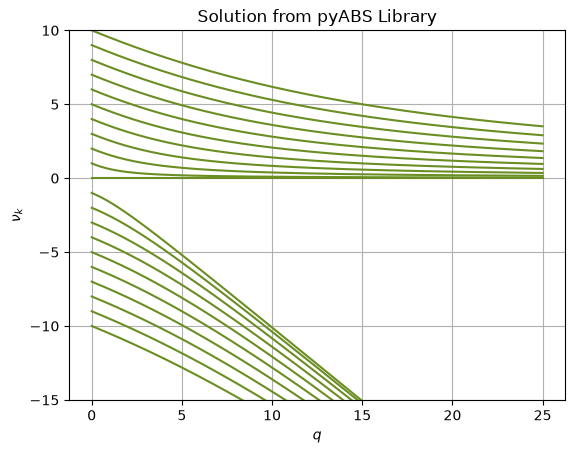

In [50]:
fig, ax = plt.subplots()
ax.set_ylim(-15,10)
#for i in range(len(modes)):
#    plt.scatter(sc, eigenscan[i])
plt.title("Solution from pyABS Library")
plt.grid()
plt.plot(sc, eigenscan_tracked, color='olivedrab')
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/pyabs_nowake.png", dpi=300)
plt.show()

compare with analytical solutions from burov
double check where the complex number went in burov

In [45]:
#analytic solutions
#analytic eigenvalues are given as
def real_eigen(n_max, q):
    modes = np.arange(-n_max, (n_max)+1, dtype=int)
    soln=[]
    for i in modes:
        if(i >= 0):
            soln.append(-q/2 + np.sqrt((q**2)/4 + i**2))
        if(i < 0):
            soln.append(-q/2 - np.sqrt((q**2)/4 + i**2))
    return soln

real_scan = []
#print(eigenscan_tracked)
analytical_solutions = []
for i, q in enumerate(sc):
    real_scan.append(real_eigen(n_max, q))
    


#print(eigenscan_tracked)
np.array(real_scan).shape

(600, 21)

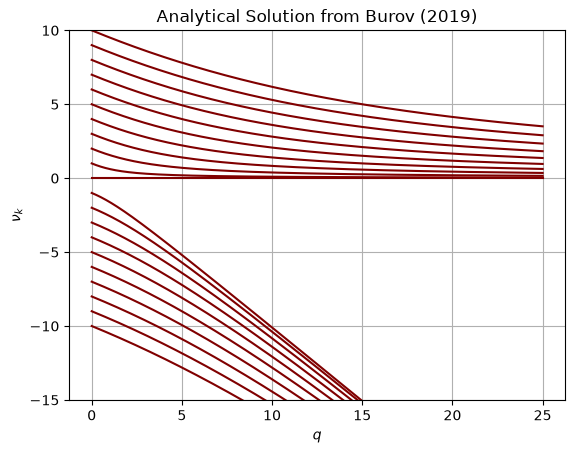

In [58]:
fig, ax = plt.subplots()
ax.set_ylim(-15,10)
plt.title("Analytical Solution from Burov (2019)")
plt.grid()
plt.plot(sc, real_scan, color='maroon')
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/analytical_nowake.png", dpi=300)
plt.show()

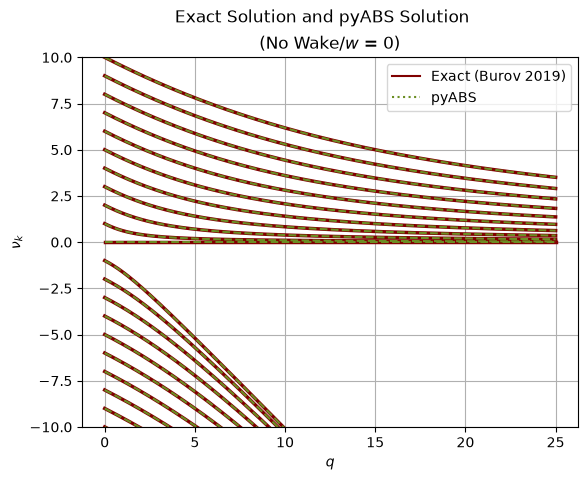

In [59]:
fig, ax = plt.subplots()
ax.set_ylim(-10,10)
plt.suptitle("Exact Solution and pyABS Solution")
plt.title(r"(No Wake/$w$ = 0)")
plt.grid()
plt.plot(sc, real_scan, color='maroon', lw=2.5)
plt.plot(sc, eigenscan_tracked, ls='--', color='olivedrab')
plt.plot([],[], color='maroon', label='Exact (Burov 2019)')
plt.plot([],[], ls=':',color='olivedrab', label="pyABS")
ax.legend()
ax.set_ylabel(r"$\nu_{k}$")
ax.set_xlabel(r"$q$")
plt.savefig("../../plots/overlay_nowake.png", dpi=300)
plt.show()